In [ ]:
Laboratório 5 – Cores em Imagens e Vídeo

In [ ]:
Exercícios Propostos
(Elabore um código separamente para cas exercício)
1. Comparação de Luminosidade: Compare o canal L∗ do CIELAB com o
canal Y do YCbCr. Qual deles parece preservar melhor os detalhes de sombreamento da
imagem original?


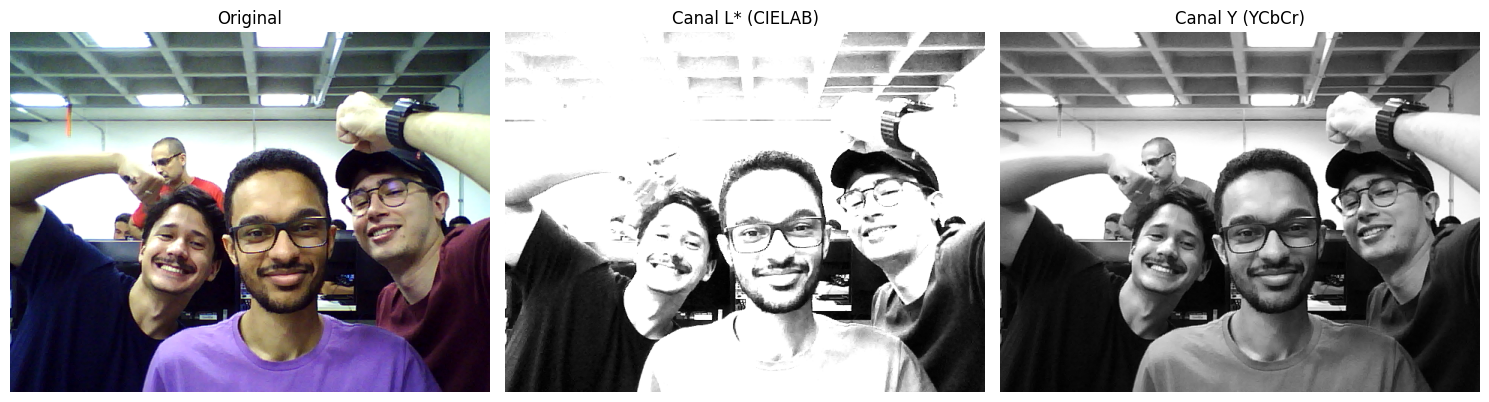

In [8]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('foto_grupo_2.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
L_star = lab[:,:,0]

ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
Y_channel = ycrcb[:,:,0]

fig, axes = plt.subplots(1,3, figsize=(15,5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(L_star, cmap='gray', vmin=0, vmax=100); axes[1].set_title('Canal L* (CIELAB)'); axes[1].axis('off')
axes[2].imshow(Y_channel, cmap='gray', vmin=0, vmax=255); axes[2].set_title('Canal Y (YCbCr)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
2. Efeito Gama: Aplique uma correção gama inversa (γ=2.2) em uma imagem clara e
observe a perda de detalhe nas áreas escuras.


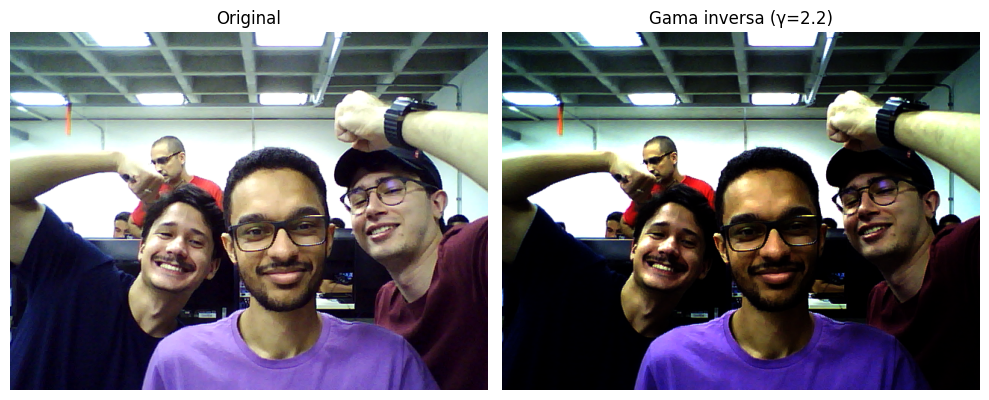

In [9]:
img = cv2.imread('foto_grupo_2.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

gamma = 2.2
img_gamma_inv = np.power(img_rgb, gamma)
img_gamma_inv = np.clip(img_gamma_inv, 0, 1)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_gamma_inv); axes[1].set_title(f'Gama inversa (γ={gamma})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
3. Filtro de Cor: Use o espaço YCbCr para remover a cor de uma imagem (torná-la escala
de cinza) zerando os canais Cb e Cr e reconstruindo-a em RGB.


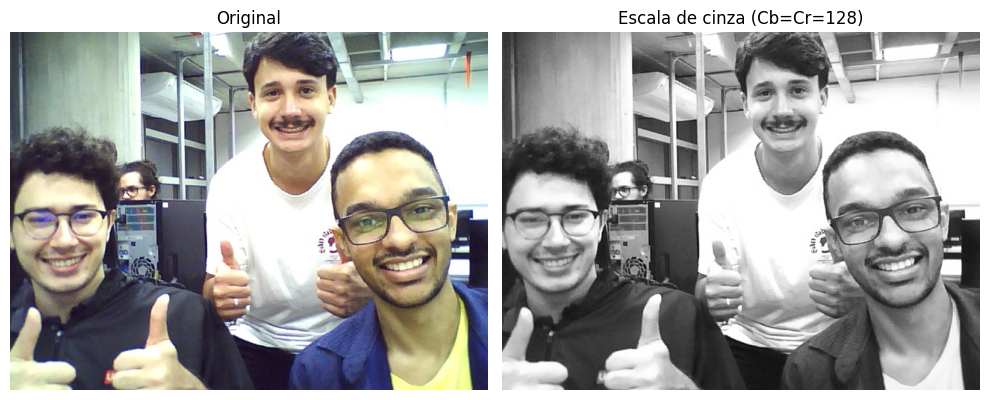

In [3]:
img = cv2.imread('grupo1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb).astype(np.float32)
ycrcb[:,:,1] = 128.0
ycrcb[:,:,2] = 128.0

img_gray = cv2.cvtColor(ycrcb.astype(np.uint8), cv2.COLOR_YCrCb2BGR)
img_gray_rgb = cv2.cvtColor(img_gray, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_gray_rgb); axes[1].set_title('Escala de cinza (Cb=Cr=128)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
4. O Desafio do Semáforo ou Objeto Colorido: Escolha uma imagem que contenha
objetos com as cores primárias bem definidas (ex: um semáforo, peças de LEGO ou frutas).
▪ (a). Tente segmentar um objeto específico usando o espaço RGB (definindo limites para
R, G e B separadamente).
▪ (b). Realize a mesma segmentação usando o espaço HSV.
▪ (c). Compare os resultados: qual método foi mais fácil de configurar? Qual lidou melhor
com as áreas de sombra do objeto?

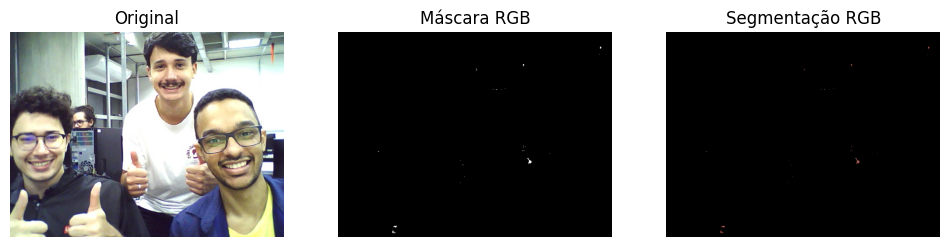

In [6]:
img = cv2.imread('grupo1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lower_red = np.array([150, 0, 0], dtype=np.uint8)
upper_red = np.array([255, 100, 100], dtype=np.uint8)
mask_rgb = cv2.inRange(img_rgb, lower_red, upper_red)
seg_rgb = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_rgb)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask_rgb, cmap='gray'); plt.title('Máscara RGB'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(seg_rgb); plt.title('Segmentação RGB'); plt.axis('off')
plt.show()

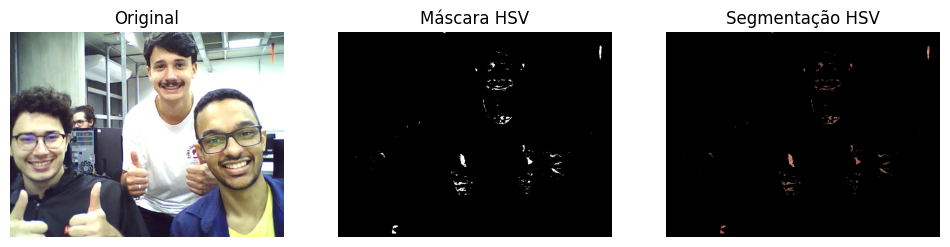

In [7]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 100, 100])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_hsv = cv2.bitwise_or(mask1, mask2)
seg_hsv = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_hsv)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask_hsv, cmap='gray'); plt.title('Máscara HSV'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(seg_hsv); plt.title('Segmentação HSV'); plt.axis('off')
plt.show()

In [ ]:
ELABORAÇÃO DE PROGRAMAS COM A WEBCAM:
3.6. Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as operações de correção
de ponto branco, e a correção gama, mostrando na tela o resultado em tempo real, permitindo ao
operador escolher a visualização da imagem original, correção ponto branco, ou correção gama, ou
ambas. Grave um video demonstrativo com os integrantes do grupo.

In [ ]:
import cv2
import numpy as np

# Referência de branco (luz do dia D65)
target_wp = np.array([1.0, 1.0, 1.0])
source_wp = np.array([0.8, 0.8, 0.5])  # supondo iluminação quente

cap = cv2.VideoCapture(0)
mode = 0  # 0: original, 1: white point, 2: gamma, 3: both

def white_point_correction(img, src, tgt):
    corrected = img * (tgt / src)
    return np.clip(corrected, 0, 1)

def apply_gamma(img, gamma=2.2):
    # correção gama: C_linear^(1/gamma)
    img_corrected = np.power(img, 1.0/gamma)
    return np.clip(img_corrected, 0, 1)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.flip(frame, 1)
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) / 255.0

    if mode == 0:
        out = img_rgb
    elif mode == 1:
        out = white_point_correction(img_rgb, source_wp, target_wp)
    elif mode == 2:
        out = apply_gamma(img_rgb)
    elif mode == 3:
        out = white_point_correction(img_rgb, source_wp, target_wp)
        out = apply_gamma(out)

    out_bgr = cv2.cvtColor((out*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.putText(out_bgr, ['Original','Ponto Branco','Gama','Ambos'][mode], (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow('Correção de Cor', out_bgr)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('0'): mode = 0
    elif key == ord('1'): mode = 1
    elif key == ord('2'): mode = 2
    elif key == ord('3'): mode = 3
    elif key == 27: break

cap.release()
cv2.destroyAllWindows()

In [ ]:
3.7. Elabore um programa para realizar continuamente sobre a imagem da WEBCAM a detecção de uma cor
pelo método HSV, mostrando lado-a-lado na tela a imagem original, e a imagem somente com as partes
detectadas. Grave um video demonstrativo com os integrantes do grupo.


In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

# Faixas HSV para verde (exemplo)
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.flip(frame, 1)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask = cv2.inRange(hsv, lower_green, upper_green)
    mask = cv2.erode(mask, None, iterations=1)
    mask = cv2.dilate(mask, None, iterations=2)

    result = cv2.bitwise_and(frame, frame, mask=mask)

    # Exibir lado a lado
    vis = np.hstack((frame, result))
    cv2.putText(vis, 'Original', (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    cv2.putText(vis, 'Detectado (verde)', (frame.shape[1]+10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    cv2.imshow('Detecção HSV', vis)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
5) Questões de Análise do Processamento de Cores: elabore as respostas para cada uma das questoes
abaixo em forma de texto e/ou figuras, e apresente na parte de Análise e Discussão do relatório.
a) Sobre Ponto Branco e Constância de Cor (Seção 4.1.11): Por que a correção de ponto branco é
considerada uma "transformação de adaptação cromática"?


In [ ]:
A correção de ponto branco (ex.: von Kries) simula a adaptação do olho humano a diferentes iluminantes, ajustando os ganhos
dos canais de cor para que objetos brancos permaneçam brancos, compensando a cor da luz.

In [ ]:
b) Espaços Independentes vs. Dependentes (Seção 4.1.12 e 4.2.3): Qual a principal diferença
prática entre o espaço de cores CIE XYZ e o sRGB? Por que não exibimos imagens diretamente
em XYZ nos monitores comuns?


In [ ]:
XYZ é um espaço absoluto e independente de dispositivo, que cobre todas as cores visíveis. sRGB é um espaço de saída 
padronizado para monitores. Não exibimos imagens em XYZ porque os pixels do monitor esperam valores no espaço sRGB 
(após a matriz de conversão e correção gama); mostrar diretamente valores XYZ resultaria em cores incorretas.

In [ ]:
c) A Necessidade da Correção Gama (Seção 4.1.13): Durante a aula, aplicamos a correção
gama Ccorrected=C
(1/γ)
linear . O que aconteceria com a percepção das sombras em uma
imagem se essa correção fosse omitida?


In [ ]:
Sem a correção gama, as intensidades escuras ficariam comprimidas, resultando em perda de detalhes nas sombras e aumento 
artificial do contraste em áreas escuras, enquanto as altas luzes saturariam. A imagem pareceria mais escura e com menos nuance.

In [ ]:
d) Percepção Humana e o Modelo CIELAB (Seção 4.1.14): O modelo L∗a∗b∗ é frequentemente
chamado de "perceptualmente uniforme". O que isso significa em termos de distância entre
cores?


In [ ]:
Significa que uma mesma distância numérica (ΔE) entre duas cores corresponde a uma diferença percebida semelhante pelo olho 
humano, independentemente da região do espaço de cor. Isso é essencial para medição de diferenças de cor e algoritmos que
dependem de similaridade perceptual.

In [ ]:
e) Engenharia de Vídeo e YCbCr (Seção 4.3.4): No experimento de visualização, os canais Cb e Cr
parecem muito mais "suaves" ou "borrados" que o canal Y . Como a compressão de vídeo
(como JPEG ou MPEG) utiliza essa característica para reduzir o tamanho dos arquivos?


In [ ]:
Os canais de crominância (Cb, Cr) são subamostrados e quantizados com menos bits porque o sistema visual humano é menos sensível 
a detalhes de cor do que de luminância. Essa suavidade inerente permite reduzir drasticamente o tamanho do arquivo sem perda 
perceptível de qualidade.

In [ ]:
f) Representação Cilíndrica e Robustez (Seção 4.2.3): Ao realizar a segmentação de uma região com
cor uniforme, por que o canal H (Hue) do modelo HSV é frequentemente preferido em relação
aos canais do modelo RGB quando a imagem possui variações de iluminação (sombras e
reflexos)?

In [ ]:
O matiz (H) representa o tipo de cor independentemente da intensidade (V) e da saturação (S). Variações de iluminação afetam 
principalmente V, enquanto H permanece aproximadamente constante para superfícies coloridas uniformes. Por isso, a segmentação
por H é mais eficaz e estável sob sombras e reflexos do que a segmentação baseada em RGB.